# Prior Ridge: Regularization for FRC Rating

Gabriel Krotkov (FRC 449 & 4821)  
Mitchell G. Hung (FRC 449)  
Rosy Yu (FRC 449)  
October 4, 2026

In FRC (the FIRST Robotics Competition), there are two primary team rating models: OPR (Offensive Power Rating) and EPA (Expected Points Added). OPR is statistically efficient and unbiased, but has no memory between events and is essentially starting from scratch every event. Starting fresh every event means that OPR tends to have high variance, and often doesn’t have enough data to stabilize. EPA achieves better prediction by incorporating historical information, but trades off statistical efficiency to do so—EPA doesn’t learn from new data as fast as OPR. Prior Ridge (pRidge) applies Bayesian-inspired regularization to balance between the relatively high variance of OPR and the relatively high bias of EPA. On average over all qualifier events between 2016 and 2026, Prior Ridge overperforms OPR by 15.4% in terms of cross validated mean squared error, and overperforms EPA by 11.1% in terms of next-match-prediction error.

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

## 1 Introduction

### 1.1 Motivation: the bias-variance tradeoff

The two primary models for team rating in FRC neatly illustrate a bias-variance tradeoff common in real-world modeling. OPR[1] is a special case of linear regression, which is provably a minimum variance linear unbiased estimator. That is, if you require unbiasedness and agree with the linear regression assumptions, OPR is provably optimal ([Taboga 2021](#ref-gauss_markov)). However, you can often improve an estimator’s prediction by accepting some bias to reduce variance. Statbotics’ EPA ([Statbotics 2023](#ref-statbotics_eval)) does exactly this. By incorporating information about teams’ historical performance, EPA accepts statistical bias in exchange for much faster convergence. This is a good fit for the FRC setting, where teams rarely have more than 12 qualification matches at an event (and often have fewer), so data is relatively scarce.

This leaves considerable room for optimization. Exactly how much prior information to incorporate is a hard challenge to resolve. Luckily, there’s an established body of regularization tools from regression analysis aimed specifically at solving this problem[2]. Prior Ridge (pRidge) applies those tools with a Bayesian twist to optimize the bias-variance tradeoff between OPR and EPA and pick more predictive coefficients.

### 1.2 Background

At FRC events, teams play matches in 3-team “alliances” with shared results. Like in any team sport, shared results pose a challenge for rating systems—it’s hard to parse out individual team performance from alliance–level results. Taking a team’s average alliance score and dividing by 3 is a reasonable first guess at their offensive contribution—but the FRC community has developed better methods for team rating.

#### 1.2.1 FRC Linear Regression (OPR)

One influential rating method is OPR (“Offensive Power Rating”), described in Eugene Fang’s The Blue Alliance blog ([Fang 2017](#ref-opr_blog)). OPR is a special case of multiple linear regression with a zero intercept. We set it up as a system of equations where each team’s contribution is a variable, and each alliance’s performance is represented as an equation (ex. $red1 + red2 + red3 = redScore$). Each match generates two equations, one for the red alliance, and one for the blue alliance. OPR is then just the least-squares approximate solution to this system. This is identical to the way linear regression minimizes the squared error between predicted and actual values. More formally, the OPR equation $Mx = s$ consists of $M$ (a matrix with alliances as rows and teams as columns), $x$ (the vector of team coefficients we solve for), and $s$ (the observed alliance scores). This mirrors the standard linear regression formulation $y = X\beta$ ([James et al. 2021, sec. 3.2](#ref-ISLR)), which solves for coefficients $\beta$ by minimizing squared residuals.

#### 1.2.2 FRC Elo ratings (Statbotics EPA)

Statbotics’ EPA (“Expected Points Added”) is another popular FRC rating method. EPA ([Gupta 2023](#ref-epa_intro)) is adapted from the Elo rating system, initially designed for 1v1 Chess for 3v3 FRC. Unitless EPA, a metric very similar to Elo in its non-specificity to a certain season’s game, takes into account previous season performance for a first estimate. To produce the version of EPA used for score predictions, unitless EPA scales by the standard deviation of Week 1 scores, effectively adopting the “units” of a particular year’s points system. EPA updates are adjusted based on the “shock of victory”, modeled by $K$ and $M$. $K$ is the learning rate for EPA: a higher $K$ means that EPA adjusts more based on the result of each match. $M$ is the margin parameter, which defines how much the EPA update cares about the opposing alliance’s performance. Both $M$ and $K$ are defined piecewise in terms of the number of matches played, with $M$ increasing and $K$ decreasing as the season continues. Unlike traditional Elo, EPA is designed to be a non-zero sum model: when one team’s EPA increases, others don’t necessarily decrease, which can reflect increasing team performance over the season.

| Method            | FRC Domain Name              | Reference Implementations   |
|------------------|----------------------------|---------------------------|
| Linear Regression | OPR, Calculated Contribution | TheBlueAlliance Insights    |
| Elo Ratings       | EPA                          | Statbotics, Caleb Sykes Elo |

Table 1: Mapping FRC rating systems onto statistical methods

#### 1.2.3 Overfitting and Regularization

Overfitting is a typical modeling issue that comes from fitting your training data too closely, usually because of high model complexity. In <a href="#fig-overfitting" class="quarto-xref">Figure 1</a>, the blue dots represent training data, and the red and green curves are candidate models to fit the data. The red curve represents a complicated, high degree polynomial fit, while the green line represents a simple linear fit. The training error of the red line is exactly zero, since the model exactly intersects each dot, while the green model has some error due to random variance. Even though the red model has a lower training error than the green model, if we were to test against data outside this sample, the simpler green model is almost sure to perform better. We call the red model in this case “overfit” - that is, matching the training dataset too closely.

Regularization ([James et al. 2021, sec. 6.2.1](#ref-ISLR)) is the process of correcting for overfitting to improve the generalizability of a model. A common way to do this is by adding a penalty for complexity to the model. This forces the model optimization to weigh the cost of additional complexity against the performance gain on the training data. This can significantly improve a model’s generalizability, especially when the exact value of the penalty is carefully chosen.

<figure id="fig-overfitting">
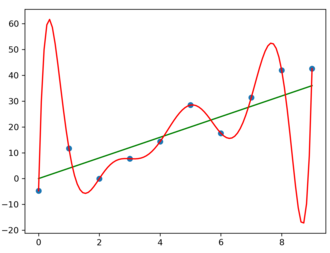
<figcaption>Figure 1: Overfitting example. Image: <a href="https://commons.wikimedia.org/wiki/File:Pyplot_overfitting.png">“Pyplot overfitting”</a> by ThirdOrderLogic, via Wikimedia Commons, licensed under <a href="https://creativecommons.org/licenses/by/4.0/">CC BY 4.0</a>.</figcaption>
</figure>

## 2 Methods

### 2.1 Prior Ridge Model

The Prior Ridge model is based on Ridge Regression ([James et al. 2021, sec. 6.2.1](#ref-ISLR)), which is a regularized version of ordinary least squares regression. The loss function for ridge regression includes a penalty term scaled by $\lambda$, the regularization parameter, which pushes all the coefficients in the model fit towards zero by penalizing large coefficients. This introduces some bias (towards zero), in exchange for considerably reducing estimate variance. In many model settings, this is a good tradeoff, and the simpler regularized model generalizes better than the optimal fit on training data. However, we can do better than regularizing towards zero. If we have an informative prior - that is, a good guess going into the event about the team’s rating - we can instead regularize towards *that* by penalizing the distance from the priors rather than penalizing the magnitude of the coefficients (derivation in <a href="#sec-derivation" class="quarto-xref">Section 5.1</a>). Statbotics EPA provides us with exactly that - a very good guess as to the team’s actual per-match contribution. Prior Ridge is essentially OPR, with a trick layered on top: regularize towards pre-event Statbotics EPA as a prior. While the fundamental model still works with other priors (for example, season max OPR), we chose Statbotics EPA for familiarity and to explicitly optimize the balance between major rating methods.

$$
\begin{aligned}
\text{OLS:} \quad \hat{\beta} &= (X^TX)^{-1}(X^Ty) \\
\text{Ridge:} \quad \hat{\beta} &= (X^TX + \lambda I)^{-1}(X^Ty) \\
\text{pRidge:} \quad \hat{\beta} &= (X^TX + \lambda I)^{-1}(X^Ty + \lambda \beta_0)
\end{aligned}
$$

### 2.2 Picking $\lambda$

Picking a good value of $\lambda$ is the core challenge to making pRidge effective. $\lambda$ controls bias-variance balance ([James et al. 2021, sec. 2.2.2](#ref-ISLR)) between the priors and new data. On one hand, pRidge with $\lambda = 0$ is simply equivalent to OPR. On the other, pRidge with $\lambda = \infty$ makes predictions solely based on the EPA priors without any update. To optimize the choice of $\lambda$, we use leave-one-out cross validation (LOOCV) ([James et al. 2021, 200–203](#ref-ISLR)) to evaluate a grid of $\lambda$ choices and select the one with minimal LOOCV mean squared error (MSE). $\lambda$ is re-optimized with each new fit of the pRidge model to data. To build intuition about $\lambda$, it can be interpreted as a number of pseudo-matches per team weighting the prior. pRidge is equivalent to least squares after adding $\lambda$ solo appearances per team, with each scoring exactly the team’s prior.

We chose a $\lambda$ grid of all values between 0.01 and 20 evenly spaced on a log scale. Keeping the lower limit above 0 guarantees that the matrix is positive-definite, while 20 is an arbitrarily chosen upper bound based on exploratory cross validation plots (for an example, <a href="#fig-severn-cv" class="quarto-xref">Figure 2</a>). This upper limit is higher than the number of qualification matches teams typically play (usually no more than 12), which helps build intuitive justification. Searching the grid on a log scale instead of a linear scale helps preserve computational effort by allocating precision to the more useful part of the range. For instance, the difference between $\lambda = 16.2$ and $\lambda = 16$ is much less meaningful than the difference between $\lambda = 1.2$ and $\lambda = 1$.

[1] We will refer to linear regression in an FRC context as OPR for familiarity, although other names outlined in <a href="#tbl-methods" class="quarto-xref">Table 1</a> may be more descriptive.

[2] In fact, in NBA sports analytics (a similar data setting to FRC), RAPM ([Nguyen and Yurko 2024](#ref-rapm_cmu)) is an example of using regularization to improve on ordinary least squares regression popular since at least 2017 ([Jacobs 2017](#ref-rapm_blog)).

In [ ]:
# 2025 Severn District (2025mdsev), from the cached raw data
load("data/raw/year_2025.rda")
severn <- year_data$event_data[["2025mdsev"]]
rm(year_data)

# Pre-event EPA priors; team_events and the design columns are both in team
# number order
severn_priors <- sapply(severn$team_events, function(te) te$epa$stats$start)
severn_design <- as.matrix(lineup_design_matrix(severn$matches))
severn_response <- c(severn$matches$blue_score, severn$matches$red_score)
lambda_grid <- exp(seq(log(0.01), log(20), length.out = 100))

# LOOCV MSE across the lambda grid, using only the first n_matches matches
severn_cv <- function(n_matches) {
  n <- nrow(severn$matches)
  rows <- c(seq_len(n_matches), n + seq_len(n_matches))
  mses <- pridge_lambda_cv(
    severn_design[rows, ], severn_response[rows], severn_priors,
    lambda_grid, plot_mses = FALSE, n_cores = 1
  )
  tibble(lambda = lambda_grid, mse = mses)
}

cv_plot <- function(cv) {
  best <- slice_min(cv, mse, n = 1)
  ggplot(cv, aes(x = lambda, y = mse)) +
    geom_line() +
    geom_vline(xintercept = best$lambda, lty = 2, colour = "darkred") +
    annotate("label", x = best$lambda, y = Inf, vjust = 1.3,
             label = sprintf("lambda == %.2f", best$lambda), parse = TRUE) +
    scale_x_log10() +
    theme_bw() +
    labs(x = expression(lambda), y = "LOOCV MSE")
}

``` r
cv_plot(severn_cv(16))
cv_plot(severn_cv(nrow(severn$matches)))
```

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div id="cell-fig-severn-qm16" class="cell" width="50.0%" data-layout-align="left">
<div class="cell-output-display">
<figure id="fig-severn-qm16">
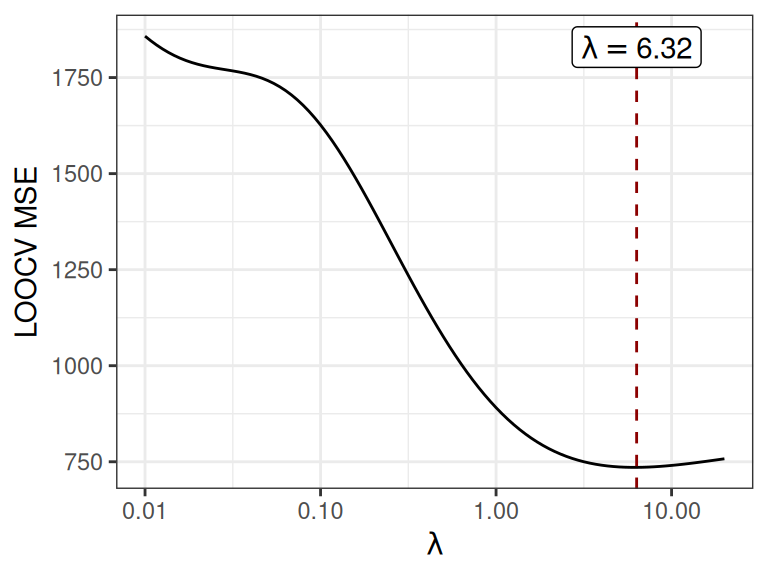
<figcaption>(a) With 16 matches complete</figcaption>
</figure>
</div>
</div></td>
<td style="text-align: left;"><div id="cell-fig-severn-full" class="cell" width="50.0%" data-layout-align="left">
<div class="cell-output-display">
<figure id="fig-severn-full">
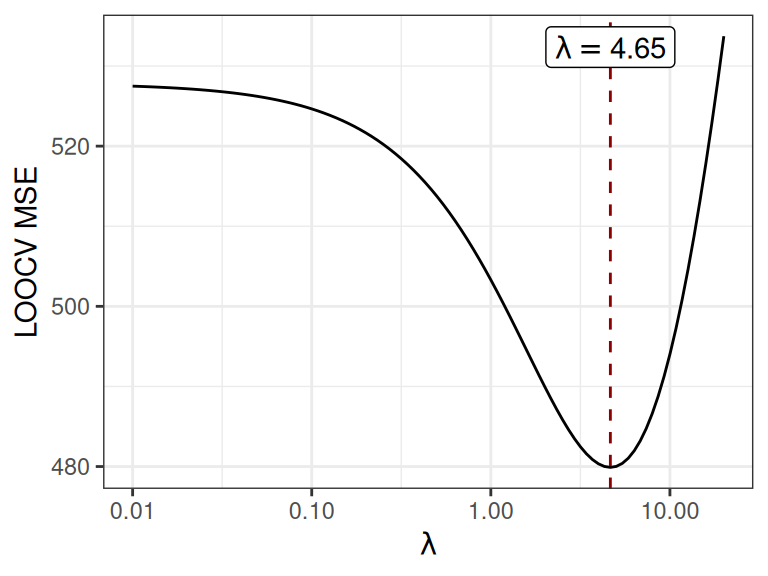
<figcaption>(b) With all matches complete</figcaption>
</figure>
</div>
</div></td>
</tr>
</tbody>
</table>

Figure 2: pRidge Cross Validation for 2025 Severn District

### 2.3 Cross validation evaluation against OPR

Both pRidge and OPR are fundamentally regression models, which makes comparing their performance easier. To evaluate the performance of pRidge against OPR, we used 4-fold cross validation on both models so all matches were represented in the test set at least once for each model, and then averaged the test MSE across folds. To preserve the separation of $\lambda$ selection and model evaluation, we nested the LOOCV for $\lambda$ selection inside the 4-fold cross validation for model evaluation. This also drove the choice of $k = 4$: this limited the computational cost for nested cross validation loops.

### 2.4 Next-match-prediction evaluation against EPA

Selecting a fair comparison between pRidge and EPA is less direct, because pRidge is order-invariant while EPA is order-dependent. To evaluate between the models fairly, we designed a “next-match prediction” procedure as follows. For each match at each event, starting at the first match (i) for which OPR was valid to compute, compute a prediction for match (i + 1) for both pRidge and EPA based only on data up to match (i). Both models predict an alliance’s score by summing each team’s rating value. This gives us a prediction for each match after match (i) from which we can calculate an MSE for both models.

### 2.5 Estimating % improvement

For both the OPR and EPA baseline evaluations, we computed the % improvement against the baseline as below, then took the mean across all events and across years to estimate pRidge’s improvement against baseline models. We established the uncertainty in mean percent improvements with a 95% bootstrap ([Lomuscio 2023](#ref-uva_bootstrap)) confidence interval with 1 million replications.

$$
\%\ \text{improvement} = \frac{\text{MSE}_{\text{baseline}} - \text{MSE}_{\text{pRidge}}}{\text{MSE}_{\text{baseline}}}
$$

### 2.6 Data

We used the TBA v3 API to access data from frc-events.firstinspires.org to evaluate the performance of pRidge, EPA, and OPR. We chose to use qualification matches from all regional and district qualifier events between 2016 and 2026 (n = 1389), excepting events in 2020 and 2021 to avoid seasons affected by the COVID-19 pandemic. We excluded playoff matches since playoff alliances develop meaningfully different dynamics than qualification matches with repeat partners and higher stakes. We decided to start data collection in 2016 for API consistency and to avoid Recycle Rush, a very atypical FRC game.

In our dataset, we were unable to compute a percent improvement for 6 events when comparing to OPR, and 6 events when comparing to EPA. These events in both cases were the 4 2026 Israel district events, 2022 Nanjing Regional, and the 2023 Izmir Regional, all of which were canceled.

## 3 Results

In [ ]:
# Per-event percent improvement over a baseline, one box per year or week
imp_plot <- function(results, group, x_label, y_label, breaks = waiver()) {
  ggplot(results, aes(x = as.character({{ group }}), y = pct_imp / 100)) +
    geom_boxplot(width = 0.6, alpha = 0.8, fill = "darkred") +
    geom_quasirandom(alpha = 0.4, shape = 21, size = 1, width = 0.4) +
    geom_hline(yintercept = 0, lty = 2) +
    coord_flip() +
    theme_bw() +
    scale_y_continuous(breaks = breaks, labels = scales::percent) +
    scale_x_discrete(limits = rev) +
    labs(x = x_label, y = y_label)
}
epa_breaks <- seq(-0.6, 0.7, by = 0.2)

``` r
imp_plot(opr, year, "Year", "% improvement in cross-validated MSE")
imp_plot(opr, week + 1, "Week", "% improvement in cross-validated MSE")
imp_plot(epa, year, "Year", "% improvement in next-match-prediction MSE",
         breaks = epa_breaks)
imp_plot(epa, week + 1, "Week", "% improvement in next-match-prediction MSE",
         breaks = epa_breaks)
```

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div id="cell-fig-opr-year" class="cell" width="50.0%" data-layout-align="left">
<div class="cell-output cell-output-stderr">
<pre><code>Warning: Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).</code></pre>
</div>
<div class="cell-output cell-output-stderr">
<pre><code>Warning: Removed 6 rows containing missing values or values outside the scale range
(`position_quasirandom()`).</code></pre>
</div>
<div class="cell-output-display">
<figure id="fig-opr-year">
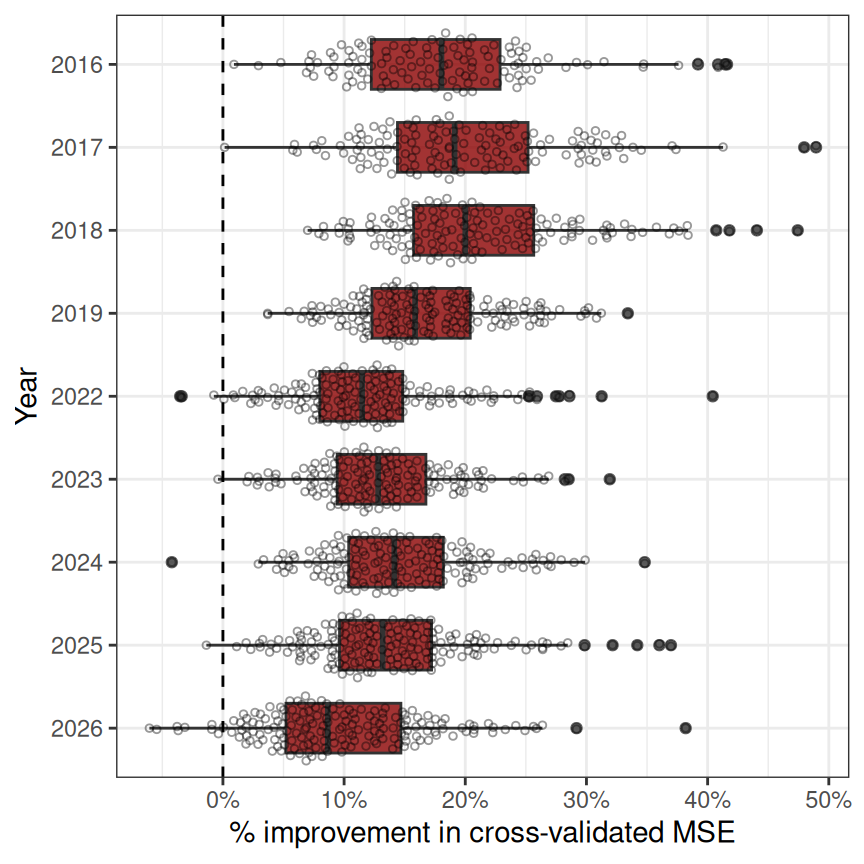
<figcaption>(a) By year, OPR baseline</figcaption>
</figure>
</div>
</div></td>
<td style="text-align: left;"><div id="cell-fig-opr-week" class="cell" width="50.0%" data-layout-align="left">
<div class="cell-output cell-output-stderr">
<pre><code>Warning: Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).</code></pre>
</div>
<div class="cell-output cell-output-stderr">
<pre><code>Warning: Removed 6 rows containing missing values or values outside the scale range
(`position_quasirandom()`).</code></pre>
</div>
<div class="cell-output-display">
<figure id="fig-opr-week">
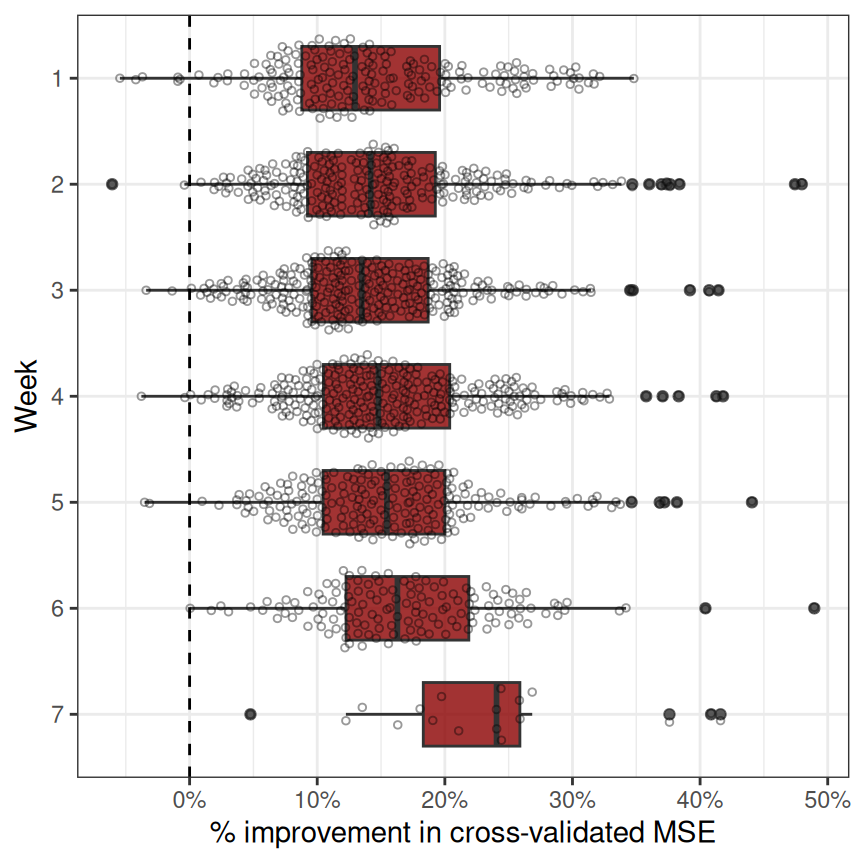
<figcaption>(b) By week, OPR baseline</figcaption>
</figure>
</div>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div id="cell-fig-epa-year" class="cell" width="50.0%" data-layout-align="left">
<div class="cell-output cell-output-stderr">
<pre><code>Warning: Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).</code></pre>
</div>
<div class="cell-output cell-output-stderr">
<pre><code>Warning: Removed 6 rows containing missing values or values outside the scale range
(`position_quasirandom()`).</code></pre>
</div>
<div class="cell-output-display">
<figure id="fig-epa-year">
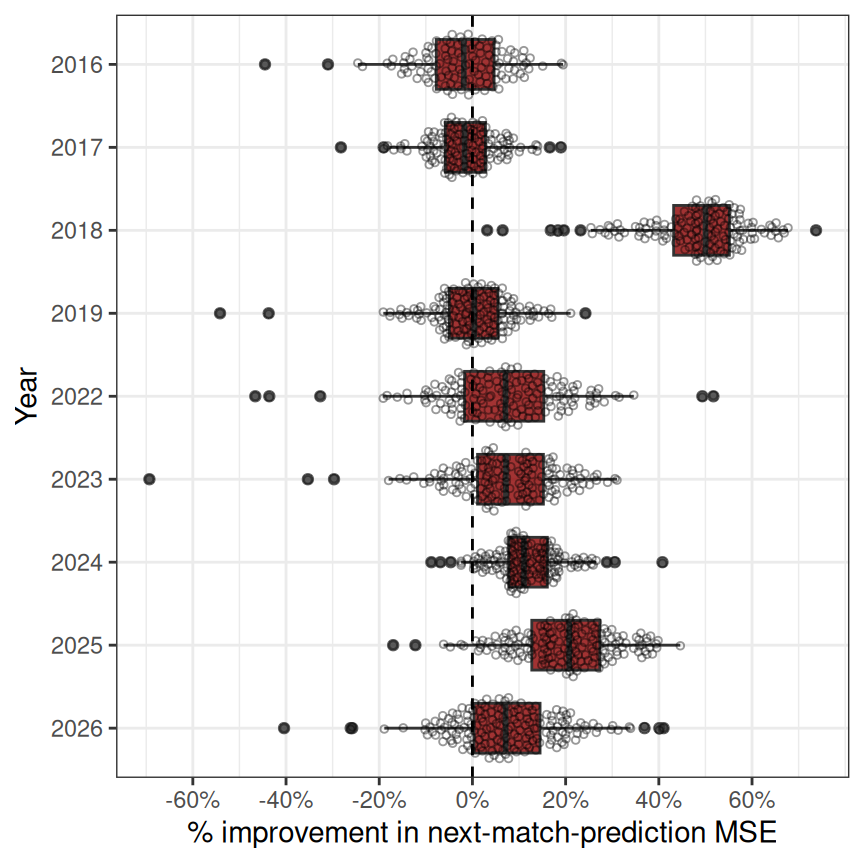
<figcaption>(c) By year, EPA baseline</figcaption>
</figure>
</div>
</div></td>
<td style="text-align: left;"><div id="cell-fig-epa-week" class="cell" width="50.0%" data-layout-align="left">
<div class="cell-output cell-output-stderr">
<pre><code>Warning: Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).</code></pre>
</div>
<div class="cell-output cell-output-stderr">
<pre><code>Warning: Removed 6 rows containing missing values or values outside the scale range
(`position_quasirandom()`).</code></pre>
</div>
<div class="cell-output-display">
<figure id="fig-epa-week">
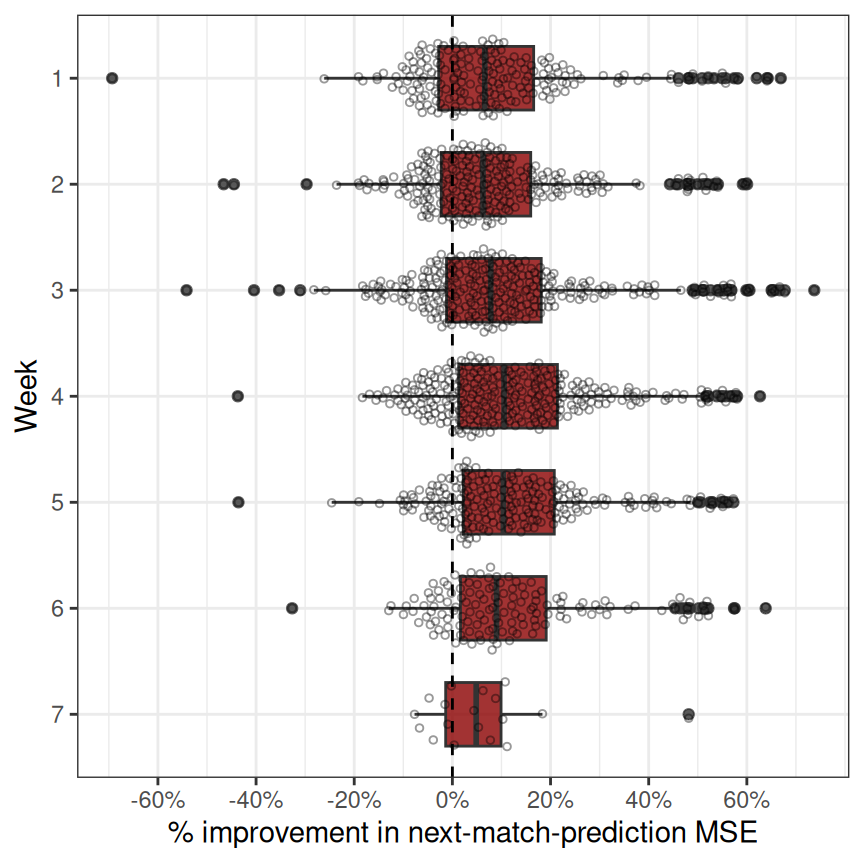
<figcaption>(d) By week, EPA baseline</figcaption>
</figure>
</div>
</div></td>
</tr>
</tbody>
</table>

Figure 3: pRidge performance comparison against baseline

In [ ]:
fmt_ci <- function(bounds) {
  sprintf("(%s, %s, %s)",
          pct(bounds$lower), pct(bounds$median), pct(bounds$upper))
}
tibble(
  Year = bounds_opr$year,
  `# Events` = bounds_opr$n_events,
  `OPR Baseline` = fmt_ci(bounds_opr),
  `EPA Baseline` = fmt_ci(bounds_epa)
) |>
  knitr::kable(align = "lrcc")

In [ ]:
bind_rows(OPR = bounds_opr, EPA = bounds_epa, .id = "baseline") |>
  mutate(year = factor(year, levels = rev(bounds_opr$year)),
         baseline = factor(baseline, levels = c("OPR", "EPA"))) |>
  ggplot(aes(x = median, y = year, colour = baseline)) +
  geom_vline(xintercept = 0, colour = "grey60") +
  geom_errorbar(aes(xmin = lower, xmax = upper), orientation = "y",
                width = 0.4,
                position = position_dodge(width = 0.6, orientation = "y")) +
  geom_point(shape = 15, size = 2.5,
             position = position_dodge(width = 0.6, orientation = "y")) +
  scale_colour_manual(values = c(OPR = "#a7000a", EPA = "forestgreen")) +
  theme_bw() +
  theme(legend.position = "top") +
  labs(x = "% improvement over baseline (positive favors pRidge)",
       y = NULL, colour = "Baseline")

### 3.1 Comparison against OPR

In terms of cross validated MSE, pRidge improves on OPR by an average of 15.4% across all qualifier events between 2016 and 2026. The 95% bootstrap confidence intervals are outlined in <a href="#tbl-bootstrap" class="quarto-xref">Table 2</a>. The confidence interval for the mean ranges between 15.0% and 15.8%, and no yearwise interval covers 0 or below. Across all 1389 events in the dataset, pRidge underperformed OPR at only 14 of them, 8 of those events being in 2026.

Plotting percent improvement against year (<a href="#fig-opr-year" class="quarto-xref">Figure 3 (a)</a>) shows some yearly variation, which appears to mostly be driven by the fit of the OPR model to that year’s game. For example, pRidge improves on OPR the least in 2026, by only 10.0% on average. The 2026 game features primarily linear, uncapped scoring and limited game piece scarcity, which lend themselves very well to OPR’s linearity assumptions. By comparison, pRidge overperforms OPR by the most in 2018, by 21.3% on average. The 2018 game relied on time-based scoring and had a snowball dynamic: alliances that won the scale overwhelmingly won the match ([Marra 2018](#ref-powerup_blog)), and a scale tipped in your favor was easier to score on. Neither of those dynamics lend themselves well to OPR’s key assumptions.

There may also be meaningful “era” effects. pRidge overperforms OPR more in pre-pandemic seasons (average 19.2% improvement over 2016-2019) than in post-pandemic seasons (12.7% improvement over 2022-2026.) Team sustainability challenges through the pandemic, the removal of bag & tag, the proliferation of swerve drive, and increasing COTS value all contribute to major differences in the program between those seasons and may influence this.

The performance of pRidge compared to an OPR baseline is plotted in <a href="#fig-opr-week" class="quarto-xref">Figure 3 (b)</a>. Over weeks of the season, pRidge appears to improve slightly better on average at later events, but it is important to note the small sample size for week 7 qualifying events - we have only 18 such events in our dataset.

### 3.2 Comparison against EPA

In terms of next-match-prediction error, pRidge improves on EPA by an average of 11.1% across all qualifier events between 2016 and 2026. The 95% bootstrap confidence interval for the mean ranges between 10.2% and 12.1%. Yearwise confidence intervals for pRidge’s mean % improvement (<a href="#tbl-bootstrap" class="quarto-xref">Table 2</a>) cover 0 for 2019, are below 0 for 2016 and 2017, and are above 0 for every other year in the dataset.

pRidge overperforms EPA by the most in 2018 by an average of 47.8%, far more so than any other year. Our best explanation for this is that the snowball dynamics in the 2018 game lent themselves to blowouts that were well explained by prior information. These blowouts might challenge rating systems to update well, but regularizing over them could smooth over the issue. Even discarding 2018, pRidge improves on EPA by an average of 6.75% of next-match-prediction error on this dataset.

There may also be “era” differences in pRidge’s performance compared to EPA, but they are more gradual than with OPR, and require ignoring 2018. Discarding 2018, pRidge actually underperforms EPA by 1.1% on average pre-pandemic, but overperforms EPA by 10.7% on average post-pandemic. It’s initially unintuitive that regularizing towards EPA could produce results that underperform EPA, but remember that we’re specifically regularizing towards the *pre-event* EPA. pRidge underperforming EPA in a particular year implies that the OPR update to the priors was less informative than the EPA update to the priors.

The performance of pRidge compared to an EPA baseline is plotted in <a href="#fig-epa-week" class="quarto-xref">Figure 3 (d)</a>. Over the weeks of the season, pRidge appears mostly steady in comparison to EPA. Again, there are too few week 7 qualifying events (n = 18) to make inferences about the late-season dynamics.

## 4 Discussion

Prior Ridge gives a meaningful, reasonably consistent improvement in team rating on OPR and EPA baselines. Against both baselines, pRidge’s relative performance appeared to change pre- and post-pandemic; improving against the EPA baseline, and reducing in improvement against the OPR baseline.

### 4.1 Limitations

Prior Ridge inherits the limitations of the models it is built on. Like OPR, it does not model interaction effects. Like EPA, it is biased towards historical performance. It is not incorporating any new information, just balancing the bias-variance tradeoff between those two methods. As with OPR, pRidge summarizes performance in qualification matches - the alliance interaction dynamics that come out in the playoffs make modeling playoff performance substantially different.

Another noteworthy limitation: we did not evaluate the performance of Prior Ridge at the DCMP or CMP level. The differences in play patterns between qualifier events and higher levels of play may impact difference in performance between Prior Ridge and other rating systems.

### 4.2 Next Steps

There are a few clear avenues to improving on Prior Ridge. For one, the current model assumes a constant $\lambda$. However $\lambda$ could be a vector with a length equal to the number of competing teams, making the model more flexible. Optimizing $\lambda$ as a vector would be more computationally intensive, but could be a better fit for the data. This highlights another clear path to improvement for Prior Ridge: searching the $\lambda$ grid. Currently we evaluate all candidate values of $\lambda$ in the grid, but efficiently searching the solution space could make the fit much faster.

Experimenting with different priors may improve the model. For example, for late-season events, once every team has played at least once, season-max OPR may be a better prior than EPA. Additionally, comparing pRidge’s performance to OPR in a next-match-prediction framework could give more insight into how well pRidge solves OPR’s stabilization challenges. OPR is typically extremely variable until about 6 matches per team have been played; pRidge provides an automatic balancing for this by rolling off $\lambda$ as more matches are played.

## 5 Technical Appendix

Code results rely on the [scoutR](https://github.com/GKrotkov/scoutR) package, available on GitHub. To install, call `pak::pak("gkrotkov/scoutR")` in your R console. The scoutR documentation can be found at <https://gkrotkov.github.io/scoutR/>.

- pRidge testing against OPR ([code](https://github.com/GKrotkov/pRidge_eval/blob/main/R/2_pridge_opr_comparison.R))
- pRidge testing against EPA ([code](https://github.com/GKrotkov/pRidge_eval/blob/main/R/2_pridge_epa_comparison.R))
- Visualization ([code](https://github.com/GKrotkov/pRidge_eval/blob/main/R/3_pridge_viz.R))

### 5.1 Prior Ridge Coefficient Derivation

Define:

$$
\begin{aligned}
\hat{\beta}: \text{prior ridge coefficients}, \quad
\beta_0: \text{priors}, \quad
X: \text{data matrix}, \\
y: \text{response vector}, \quad
L: \text{loss function}, \quad \lambda: \text{regularization penalty}
\end{aligned}
$$

#### Loss Function

$$
L(\hat{\beta}) = \| y - X\hat{\beta} \|_2^2 + \lambda \| \hat{\beta} - \beta_0 \|_2^2
$$

By $L_2$ norm definition:

$$
L(\hat{\beta}) = (y - X\hat{\beta})^{T} (y - X\hat{\beta}) +
\lambda (\hat{\beta} - \beta_0)^{T} (\hat{\beta} - \beta_0)
$$

#### Compute Loss Gradient

$$
\nabla_{\hat{\beta}} L(\hat{\beta})
= \nabla_{\hat{\beta}} [(y - X\hat{\beta})^{T} (y - X\hat{\beta})]
+ \lambda \nabla_{\hat{\beta}} [(\hat{\beta} - \beta_0)^{T} (\hat{\beta} - \beta_0)]
$$

Apply the chain rule and the matrix identity $\nabla_{x} (x^{T}A x) = (A + A^{T})x = 2A x$ (for symmetric $A$):

$$
\begin{aligned}
\nabla_{\hat{\beta}} L(\hat{\beta})
&= 2(y - X\hat{\beta})\nabla_{\hat{\beta}}[y - X\hat{\beta}] + \lambda * 2(\hat{\beta} - \beta_0) * \nabla_{\hat{\beta}} \hat{\beta} \\
&= -2X^T(y - X\hat{\beta}) + 2\lambda(\hat{\beta} - \beta_0)
\end{aligned}
$$

#### Set Gradient to Zero

$$
\nabla_{\hat{\beta}} L(\hat{\beta}) = 0
$$

$$
0 = -2X^{T}(y - X\hat{\beta}) + 2\lambda(\hat{\beta} - \beta_0)
$$

Simplify:

$$
\begin{aligned}
- X^{T}y + X^{T}X\hat{\beta} + \lambda \hat{\beta} - \lambda \beta_0 &= 0 \\
X^TX\hat{\beta} + \lambda\hat{\beta} &= X^Ty + \lambda\beta_0 \\
(X^{T}X + \lambda I)\hat{\beta} &= X^{T}y + \lambda \beta_0
\end{aligned}
$$

$$
\boxed{
\hat{\beta} = (X^{T}X + \lambda I)^{-1}(X^{T}y + \lambda \beta_0)
}
$$

## References

Fang, Eugene. 2017. *The Math Behind OPR – an Introduction*. The Blue Alliance Blog. <https://blog.thebluealliance.com/2017/10/05/the-math-behind-opr-an-introduction/>.

Gupta, Abhijit. 2023. *The EPA Model*. Statbotics. <https://www.statbotics.io/blog/epa>.

Jacobs, Justin. 2017. *Deep Dive of Regularized Adjusted Plus-Minus*. Squared Statistics. <https://squared2020.com/2017/09/18/deep-dive-on-regularized-adjusted-plus-minus-i-introductory-example/>.

James, Gareth, Daniela Witten, Trevor Hastie, and Robert Tibshirani. 2021. *An Introduction to Statistical Learning*. Springer Texts in Statistics. Springer. <https://doi.org/10.1007/978-1-0716-1418-1>.

Lomuscio, Samantha. 2023. *Bootstrap Estimates of Confidence Intervals*. University of Virginia Library. <https://library.virginia.edu/data/articles/bootstrap-estimates-of-confidence-intervals>.

Marra, Greg. 2018. *2018w2 Match Analysis Using the TBA API and R*. The Blue Alliance Blog. <https://blog.thebluealliance.com/2018/03/10/2018w2-match-analysis-using-the-tba-api-and-r/>.

Nguyen, Quang, and Ron Yurko. 2024. *Introduction to Regularized Adjusted Plus Minus*. CMU SCORE Module Repository. <https://ryurko.github.io/cmu_score_preprints/basketball/nba-rapm.html>.

Statbotics. 2023. *Evaluating FRC Rating Models*. Statbotics. <https://www.statbotics.io/blog/models>.

Taboga, Marco. 2021. *Gauss Markov Theorem*. Lectures on Probability Theory and Mathematical Statistics. Kindle Direct Publishing. Online appendix. <https://www.statlect.com/fundamentals-of-statistics/Gauss-Markov-theorem>.